# REINFORCE on CartPole: does a baseline help?

Three variants of Monte Carlo policy gradient on CartPole-v1, written from scratch in
PyTorch and compared over **10 seeds**:

1. **Plain REINFORCE** — advantage is the raw return G_t.
2. **Scalar baseline** — subtract the mean return of the current episode, G_t − mean(G).
3. **Value baseline** — subtract a learned V(s_t), G_t − V(s_t). This is the critic.

The comparison is run over seeds because a single run says almost nothing here —
CartPole is notoriously seed-sensitive, and an earlier two-run comparison gave the
*opposite* conclusion to the one below.

**Result, up front:** the value baseline wins on every measure — peak, final score,
stability, and seeds solved. The scalar baseline does *not* help — it reduces to a
positional constant and actively hurts stability. And all three still collapse at the
episode level, which is the motivation for PPO. Each claim is measured rather than
asserted.

In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import gymnasium as gym
import torch.nn.functional as F
from torch.optim import Adam
from torch.distributions import Categorical
import matplotlib.pyplot as plt

In [2]:
# env = gym.make("CartPole-v1", render_mode='human')
# for n in range(5):
#     state, _ = env.reset()
#     reward_ep = 0
#     while True:
#         action = env.action_space.sample()
#         state, reward, done, truncated, info = env.step(action)
#         reward_ep +=reward
#         env.render()

#         if done or truncated:
#             print(f'\r Episode: {n} Return: {reward_ep}',end="")
#             break
# env.close()

In [3]:
class Policy(nn.Module):

    def __init__(self,state_size, action_size, seed =0):
        super().__init__()
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(state_size, 32),
            nn.ReLU(),
            nn.Linear(32, action_size)
        )

    def forward(self, state, train = True):
        logits = self.net(state)
        dist = Categorical(logits=logits)
        action = dist.sample() if train else logits.argmax(dim=-1)
        logprob = dist.log_prob(action)

        return action.cpu().item(), logprob

In [4]:
env = gym.make("CartPole-v1")

In [5]:
GAMMA = 1.0
lr = .005
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Why compare over seeds, and why these controls

Everything is held fixed between the three methods except the baseline: the same seed
list (applied to policy init, NumPy, and the environment RNG), the same `.sum()`
reduction and learning rate, and the same stopping rule (greedy evaluation over 30
episodes clearing 450, checked on a 10-episode grid).

Two seeding details matter more than they look:

- **Seed once, before the training loop, then plain `reset()` each episode.** Reseeding
  to the same seed *inside* the loop starts every episode from an identical state and
  destroys start-state diversity. An earlier version did exactly that; fixing it made all
  methods look *worse*, because they now face varied starts — the real task.
- **`evaluate()` uses its own environment instance**, so evaluation never advances the
  training env's RNG and every method sees the same start-state stream for a given seed.

For the value baseline specifically, two implementation details are load-bearing:

- **V(s) is detached in the policy loss** (`advantages = returns - values.detach()`). The
  baseline theorem only holds if the baseline is treated as a constant with respect to
  the policy gradient; letting gradients flow from the policy loss into V breaks that and
  lets the "baseline" pull the policy directly. V still trains, through a separate MSE
  loss toward the observed returns.
- **The value network's parameters must actually be in the optimizer**
  (`Adam(list(policy.parameters()) + list(value_net.parameters()), lr=lr)`). An earlier
  version passed only the policy's parameters, so the MSE loss computed a gradient for V
  that was never applied: the "learned" baseline stayed frozen at its random
  initialisation for all 600 episodes. It is a silent bug — nothing errors, the value loss
  is still in the total loss, and the run still trains and still beat plain REINFORCE
  slightly, because even a fixed random state-dependent function is a valid (if useless)
  baseline. The numbers below are from the fixed version; the effect of the fix was to
  turn a marginal win into a win on every column.

In [6]:
def evaluate(policy,n_eps = 30):
    env = gym.make("CartPole-v1")
    all_returns = []
    for _ in range(n_eps):
        state, _ = env.reset()
        ep_return = 0
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            action, log_prob = policy(state_t, train=False)
            state, reward, done, truncated, info = env.step(action)
            ep_return +=reward
            if done or truncated:
                break
        all_returns.append(ep_return)

    env.close()
    return np.mean(all_returns)
                

## 1. No baseline

In [7]:
def run(env, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    policy = Policy(env.observation_space.shape[0], env.action_space.n, seed).to(device)
    optimizer = Adam(policy.parameters(), lr=lr)

    env.reset(seed=seed)          # seed the RNG once
    env.action_space.seed(seed)
    all_rewards = []
    solved_at = None 
    for n in range(600):
        state, _ = env.reset()
        ep_rewards = []
        log_probs = []
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            action, log_prob = policy(state_t)
            state, reward, done, truncated, info = env.step(action)
            ep_rewards.append(reward)
            log_probs.append(log_prob)
            if done or truncated:
                break

        G = 0
        losses = []
        for r,lp in zip(ep_rewards[::-1], log_probs[::-1]):
            G = r + GAMMA*G
            losses.append(-G*lp)
            
        losses_t = torch.cat(losses)
        losses_t.sum().backward()
        optimizer.step()
        optimizer.zero_grad()
        all_rewards.append(sum(ep_rewards))
        print(f"\rEpiseode {n} return: {sum(ep_rewards)}",end="")
        if (np.mean(all_rewards[-30:])>=300) and (n%10==0) and (solved_at is None):
            eval_score = evaluate(policy)
            if eval_score>450 and solved_at is None:
                solved_at = n
                print(f'\nSolved!! Average Score for last 30 runs: {eval_score:.2f}')

    env.close()

    return all_rewards, solved_at

In [8]:
seeds = list(range(10))
reinforce_rewards = []
reinforce_solved = []
for seed in seeds:
    print(f"\nSeed: {seed}")
    all_rewards, solved_at = run(env, seed)
    reinforce_rewards.append(all_rewards)
    reinforce_solved.append(solved_at)

reinforce_results = {
    "scores": np.array(reinforce_rewards),
    "solved_at": np.array(reinforce_solved)
}


Seed: 0
Episeode 250 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 1
Episeode 190 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 2
Episeode 260 return: 500.0
Solved!! Average Score for last 30 runs: 476.10
Episeode 599 return: 500.0
Seed: 3
Episeode 190 return: 421.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 4
Episeode 220 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 5
Episeode 200 return: 431.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 157.0
Seed: 6
Episeode 220 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 270.0
Seed: 7
Episeode 260 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 430.0
Seed: 8
Episeode 599 return: 225.0
Seed: 9
Episeode 270 return: 216.0
Solved!! Average Score for last 30 runs: 499.03
E

In [9]:
# env = gym.make("CartPole-v1", render_mode='human')
# policy.eval()
# reward_ep = 0
# for n in range(2):
#     state, _ = env.reset()
#     reward_ep = 0
#     while True:
#         state_t = torch.tensor(state).unsqueeze(0).to(device)
#         with torch.no_grad():
#             action, log_prob = policy(state_t)    
#         state, reward, done, truncated, info = env.step(action)
#         env.render()
#         reward_ep +=reward
#         env.render()

#         if done or truncated:
#             break
#     print(f'Episode: {n} Return: {reward_ep}')
# env.close()

## 2. Scalar baseline

In [10]:
def run_scalar_baseline(env, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    policy = Policy(env.observation_space.shape[0], env.action_space.n, seed).to(device)
    optimizer = Adam(policy.parameters(), lr=lr)

    env.reset(seed=seed)          # seed the RNG once
    env.action_space.seed(seed)
    all_rewards = []
    solved_at = None 

    all_rewards = []
    for n in range(600):
        state, _ = env.reset()
        ep_rewards = []
        log_probs = []
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            action, log_prob = policy(state_t)
            state, reward, done, truncated, info = env.step(action)
            ep_rewards.append(reward)
            log_probs.append(log_prob)
            if done or truncated:
                break

        G = 0
        returns = []
        for r in ep_rewards[::-1]:
            G = r + GAMMA*G
            returns.append(G)
        returns_t = torch.tensor(returns[::-1]).to(device)
        #subtracting baseline
        advantages = returns_t - returns_t.mean()

        loss = -(torch.cat(log_probs)*advantages).sum()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        all_rewards.append(sum(ep_rewards))
        print(f"\rEpiseode {n} return: {sum(ep_rewards)}",end="")
        if (np.mean(all_rewards[-30:])>=300) and (n%10==0) and (solved_at is None):
            eval_score = evaluate(policy)
            if eval_score>450 and solved_at is None:
                solved_at = n
                print(f'\nSolved!! Average Score for last 30 runs: {eval_score:.2f}')

    env.close()

    return all_rewards, solved_at

In [11]:
scalar_baseline_rewards = []
scalar_baseline_solved = []
for seed in seeds:
    print(f"\nSeed: {seed}")
    all_rewards, solved_at = run_scalar_baseline(env, seed)
    scalar_baseline_rewards.append(all_rewards)
    scalar_baseline_solved.append(solved_at)

scalar_baseline_results = {
    "scores": np.array(scalar_baseline_rewards),
    "solved_at": np.array(scalar_baseline_solved)
}


Seed: 0
Episeode 500 return: 158.0
Solved!! Average Score for last 30 runs: 489.50
Episeode 599 return: 500.0
Seed: 1
Episeode 200 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 2
Episeode 250 return: 495.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 205.0
Seed: 3
Episeode 310 return: 305.0
Solved!! Average Score for last 30 runs: 487.93
Episeode 599 return: 248.0
Seed: 4
Episeode 380 return: 285.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 133.0
Seed: 5
Episeode 200 return: 266.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 231.0
Seed: 6
Episeode 440 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 151.0
Seed: 7
Episeode 230 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 103.0
Seed: 8
Episeode 210 return: 498.0
Solved!! Average Score for last 30 runs: 484.47
Episeode 599 return: 191.0
Seed: 9
E

## 3. Value baseline

In [12]:
class Value(nn.Module):

    def __init__(self,state_size, seed =0):
        super().__init__()
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(state_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, state):

        return  self.net(state)
     

In [13]:
def run_value_baseline(env, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    policy = Policy(env.observation_space.shape[0], env.action_space.n, seed).to(device)
    value_net = Value(env.observation_space.shape[0], seed).to(device)
    optimizer = Adam(list(policy.parameters()) + list(value_net.parameters()), lr=lr)

    env.reset(seed=seed)          # seed the RNG once
    env.action_space.seed(seed)
    all_rewards = []
    solved_at = None 

    all_rewards = []
    for n in range(600):
        state, _ = env.reset()
        ep_rewards = []
        log_probs = []
        values = []
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            action, log_prob = policy(state_t)
            value = value_net(state_t)
            state, reward, done, truncated, info = env.step(action)
            ep_rewards.append(reward)
            log_probs.append(log_prob)
            values.append(value)
            if done or truncated:
                break

        G = 0
        returns = []
        for r in ep_rewards[::-1]:
            G = r + GAMMA*G
            returns.append(G)
        values_t = torch.cat(values).squeeze()
        returns_t = torch.tensor(returns[::-1]).to(device)
        #subtracting baseline
        advantages = returns_t - values_t.detach()

        loss_policy = -(torch.cat(log_probs)*advantages).sum()
        loss_value = F.mse_loss(values_t,returns_t)
        loss = loss_policy + 0.5*loss_value
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()
        all_rewards.append(sum(ep_rewards))
        print(f"\rEpiseode {n} return: {sum(ep_rewards)}",end="")
        if (np.mean(all_rewards[-30:])>=300) and (n%10==0) and (solved_at is None):
            eval_score = evaluate(policy)
            if eval_score>450 and solved_at is None:
                solved_at = n
                print(f'\nSolved!! Average Score for last 30 runs: {eval_score:.2f}')

    env.close()

    return all_rewards, solved_at

In [14]:
value_baseline_rewards = []
value_baseline_solved = []
for seed in seeds:
    print(f"\nSeed: {seed}")
    all_rewards, solved_at = run_value_baseline(env, seed)
    value_baseline_rewards.append(all_rewards)
    value_baseline_solved.append(solved_at)

value_baseline_results = {
    "scores": np.array(value_baseline_rewards),
    "solved_at": np.array(value_baseline_solved)
}


Seed: 0
Episeode 320 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 1
Episeode 170 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 314.0
Seed: 2
Episeode 280 return: 500.0
Solved!! Average Score for last 30 runs: 496.53
Episeode 599 return: 500.0
Seed: 3
Episeode 260 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 4
Episeode 180 return: 500.0
Solved!! Average Score for last 30 runs: 497.17
Episeode 599 return: 500.0
Seed: 5
Episeode 160 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 6
Episeode 210 return: 500.0
Solved!! Average Score for last 30 runs: 475.87
Episeode 599 return: 500.0
Seed: 7
Episeode 290 return: 443.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 8
Episeode 190 return: 266.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 305.0
Seed: 9
E

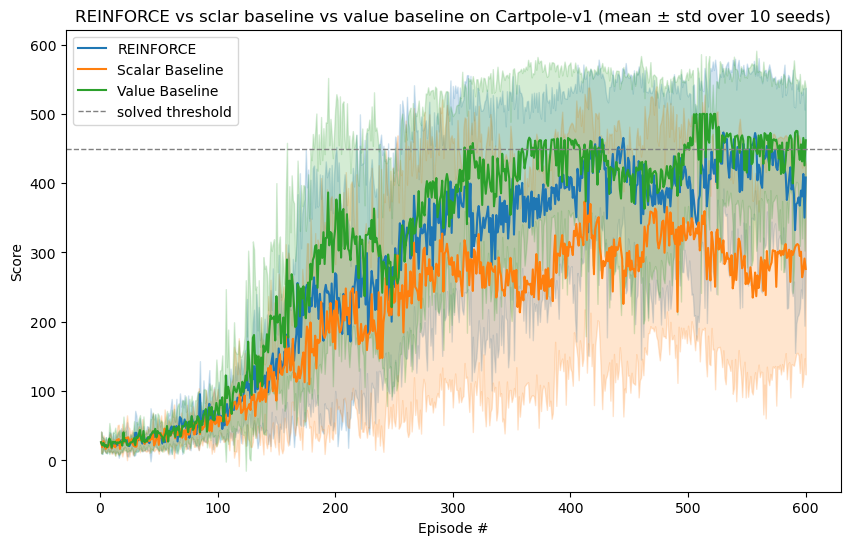

In [18]:
ALL_RESULTS = {
    "REINFORCE": (reinforce_results, "tab:blue"),
    "Scalar Baseline": (scalar_baseline_results, "tab:orange"),
    "Value Baseline": (value_baseline_results, "tab:green"),

}


def plot_mean_std(ax, data, label, color):
    mean = np.nanmean(data, axis=0)
    std = np.nanstd(data, axis=0)
    x = np.arange(1, data.shape[1] + 1)
    ax.plot(x, mean, label=label, color=color)
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)


fig, ax = plt.subplots(figsize=(10, 6))
for name, (results, color) in ALL_RESULTS.items():
    plot_mean_std(ax, results["scores"], name, color)
ax.axhline(450.0, color="gray", linestyle="--", linewidth=1, label="solved threshold")
ax.set_xlabel("Episode #")
ax.set_ylabel("Score")
ax.set_title(f"REINFORCE vs sclar baseline vs value baseline on Cartpole-v1 (mean \u00b1 std over {len(seeds)} seeds)")
ax.legend()
plt.show()

In [19]:
def summarize(name, results):
    final_scores = np.nanmean(results["scores"][:, -100:], axis=1)  # last-100-episode avg per seed
    solved = results["solved_at"]
    print(f"{name}:")
    
    for i,(seed, fs, s) in enumerate(zip(range(10), final_scores, solved)):
        scores_seed = results['scores'][i]
        solved_str = f"solved at episode {s}" if s is not None else "not solved"
        rolling_mean = pd.Series(scores_seed).rolling(window=100).mean().to_numpy()

        print(f"  seed={seed}: Reached {np.nanmax(rolling_mean)} then ended = {fs:.2f} | {solved_str}")
    print(f"  overall mean final score: {np.mean(final_scores):.2f}\n")


for name, (results, _color) in ALL_RESULTS.items():
    summarize(name, results)

REINFORCE:
  seed=0: Reached 474.21 then ended = 449.52 | solved at episode 250
  seed=1: Reached 484.51 then ended = 474.57 | solved at episode 190
  seed=2: Reached 407.41 then ended = 407.41 | solved at episode 260
  seed=3: Reached 498.02 then ended = 497.08 | solved at episode 190
  seed=4: Reached 492.15 then ended = 467.83 | solved at episode 220
  seed=5: Reached 460.96 then ended = 306.98 | solved at episode 200
  seed=6: Reached 500.0 then ended = 375.74 | solved at episode 220
  seed=7: Reached 492.58 then ended = 449.50 | solved at episode 260
  seed=8: Reached 242.08 then ended = 242.08 | not solved
  seed=9: Reached 500.0 then ended = 500.00 | solved at episode 270
  overall mean final score: 417.07

Scalar Baseline:
  seed=0: Reached 420.63 then ended = 420.63 | solved at episode 500
  seed=1: Reached 443.0 then ended = 441.68 | solved at episode 200
  seed=2: Reached 493.48 then ended = 238.93 | solved at episode 250
  seed=3: Reached 303.9 then ended = 221.31 | solved 

## Findings

Tracking the *peak* 100-episode mean per seed alongside the *final* score is what makes
the differences legible — final score alone hides both the stability story and the
scalar baseline's failure.

| | mean peak | mean final | mean drop from peak | seeds retaining ≥90% of peak |
|---|---|---|---|---|
| Plain REINFORCE | 455 | 417 | 38 | 8/10 |
| Scalar baseline | 414 | 293 | 121 | 4/10 |
| Value baseline | **477** | **458** | **19** | **9/10** |

### 1. The value baseline is the clear winner

It leads on every column: highest peak, highest final score, half the drop from peak, and
the best retention. It is also the only variant to solve all 10 seeds (plain REINFORCE
misses one), and it does so no later — mean solve episode ≈229 for both, over the seeds
plain REINFORCE solves at all. So the gain is not in how fast it gets there; it is in what
happens after.

That is what a real baseline buys. V(s) is a state-dependent estimate of expected return,
so G_t − V(s_t) is a genuine advantage — positive exactly for actions that did better than
the state warranted — rather than the positional artefact of §2. Same gradient in
expectation, much less variance in the sample.

Its one weak seed (9) fails differently from the other methods' weak seeds: it never
climbed past a 335 peak, rather than climbing to 500 and then collapsing.

### 2. The scalar baseline does not help — and hurts stability

It is the worst of the three on final score, and it collapses from its peak far more
often (only 4/10 seeds hold, one going 492 → 82). An earlier single-pair run suggested
the scalar baseline roughly halved training time; that was a two-seed fluke plus a bug in
the stopping condition, and the 10-seed picture does not support it — it is the *slowest*
of the three to solve (mean episode 300 vs ≈229).

The reason is structural. With one episode per update and gamma = 1.0, the return at
timestep t is just the number of steps remaining, so subtracting the episode mean gives

    advantage(t) = (T - t) - (T + 1) / 2

which depends only on the position t within the episode — not the state or the action. It
is a fixed positional ramp, the same for every episode of a given length: it removes the
constant positive offset (a genuine variance source) but injects a new one, because it is
recomputed each episode from that episode's own returns and its scale shifts as episode
length swings between updates. With no trust region to bound the step, that makes
destructive updates more likely. The value baseline fixes exactly this: V(s) varies with
the state and is trained toward a stable target, rather than being a per-episode
positional constant.

### 3. Catastrophic forgetting is reduced, not removed

Every seed of every method touches 500 at some point, and for two of the three methods
several then fall back for good: plain REINFORCE ends seeds at 500 → 376 and 461 → 307,
the scalar baseline at 492 → 82 and 492 → 239.

The value baseline largely removes forgetting at that scale — 9/10 seeds hold ≥90% of
their peak and the mean drop is halved. It does not remove the underlying problem, which
is still plainly visible per episode: even on seeds that end around 480, individual
episodes after the first 500-step run still fall to 15–30 steps, and seed 9 spends 56% of
its post-500 episodes below 200. Nothing constrains how far the policy moves in one
update; a lower-variance gradient makes the destructive step rarer without bounding it.

That is the cleanest possible motivation for PPO, whose clipped objective bounds exactly
this step. The next notebook adds bootstrapping (A2C); the one after adds clipping (PPO).

In [20]:
np.savez(
    "reinforce_comparison.npz",
    reinforce_scores=reinforce_results["scores"],
    reinforce_solved=reinforce_results['solved_at'],
    scalar_baseline_scores=scalar_baseline_results["scores"],
    scalar_baseline_solved=scalar_baseline_results['solved_at'],
    value_baseline_scores=value_baseline_results["scores"],
    value_baseline_solved=value_baseline_results['solved_at'],
)